In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

# Definición del problema

Contexto\
Según la Organización Mundial de la Salud (OMS), la diabetes mellitus afecta a más de 422 millones de personas en el mundo y es una de las principales causas de muerte prematura, ceguera, insuficiencia renal y amputaciones. En Chile, la Encuesta Nacional de Salud reporta una prevalencia del 12,3% en adultos, cifra que sigue en aumento. La detección temprana resulta clave, ya que en sus etapas iniciales la enfermedad puede ser completamente asintomática. Este conjunto de datos se utiliza para predecir si una paciente tiene diabetes en función de variables clínicas obtenidas en exámenes de rutina. Los registros corresponden a mujeres de ascendencia indígena Pima, población con alta predisposición genética a la diabetes tipo 2. Cada fila del dataset proporciona información clínica relevante de una paciente.

Información de atributos

1) Pregnancies: número de embarazos que ha tenido la paciente\
2) Glucose: concentración de glucosa en plasma a las 2 horas de un test oral de tolerancia (mg/dL)\
3) BloodPressure: presión arterial diastólica (mm Hg)\
4) SkinThickness: grosor del pliegue cutáneo del tríceps (mm)\
5) Insulin: nivel de insulina en suero a las 2 horas (mu U/ml)\
6) BMI: índice de masa corporal — peso(kg) / estatura(m)²\
7) DiabetesPedigreeFunction: función que estima la probabilidad de diabetes según historial familiar\
8) Age: edad de la paciente (años)\
9) Outcome: variable objetivo — 0 si no tiene diabetes, 1 si tiene diabetes

Ejemplo de un registro

| Pregnancies | Glucose | BloodPressure | BMI  | Age | Outcome |
|:-----------:|:-------:|:-------------:|:----:|:---:|:-------:|
| 6 | 148 | 72 | 33.6 | 50 | 1 |

Interpretación:
- Ha tenido 6 embarazos.
- Su glucosa es 148 mg/dL, valor que supera el umbral diagnóstico de diabetes (≥ 126 mg/dL).
- Su presión diastólica es 72 mmHg.
- Su IMC es 33.6, lo que corresponde a obesidad grado I.
- Tiene 50 años.
- Outcome = 1 indica que fue diagnosticada con diabetes.

In [2]:
df = pd.read_csv(r'C:\Vulcan_Home\mcdia500-programacion-cd-g6\raw\diabetes_raw.csv', sep=';')

In [3]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35.0,0.0,33.600,0.627,50,1
1,1,85,66,29.0,0.0,26.600,0.351,31,0
2,8,183,64,0.0,0.0,23.300,0.672,32,1
3,1,89,66,NaN,94.0,28.100,0.167,21,0
4,0,137,40,35.0,168.0,43.100,2.288,33,1
...,...,...,...,...,...,...,...,...,...
2040,5,165,77,0.0,NaN,45.943,0.346,27,1
2041,3,188,110,31.0,NaN,28.798,0.689,37,0
2042,6,102,90,39.0,NaN,35.771,0.666,28,0
2043,3,104,72,NaN,NaN,27.694,0.714,27,0


In [4]:
df.shape

(2045, 9)

# En este notebook aplicaremos las diferentes etapas del preprocesamiento:

I.- Preprocesamiento de los Datos.

1. Exploración inicial del dataset.

2. Limpieza de datos: corrección de formatos incorrectos, ceros imposibles y outliers extremos.

3. Convertir valores string en valores numéricos. Utilizando Label encoding y One hot encoding.

4. Corregir valores nulos.

5. Eliminar características innecesarias.

6. Escalarización de los datos: normalización y estandarización.

7. Validación técnica del dataset final.

8. Exportación del dataset procesado.

---
# 1. Exploración inicial del dataset

Antes de cualquier transformación se realiza un diagnóstico completo del dataset: tipos de datos, valores nulos, duplicados, estadísticas descriptivas y distribución de la variable objetivo. Este paso permite identificar los problemas de calidad que se abordarán en la limpieza.

In [5]:
# Tipos de datos por columna
# BloodPressure aparece como str porque mezcla números con texto ('88 mmHg', '?')
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                object
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [6]:
# Información general del dataset: tipos, memoria y conteo de valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2045 entries, 0 to 2044
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2045 non-null   int64  
 1   Glucose                   2045 non-null   int64  
 2   BloodPressure             2045 non-null   object 
 3   SkinThickness             1881 non-null   float64
 4   Insulin                   1800 non-null   float64
 5   BMI                       2045 non-null   float64
 6   DiabetesPedigreeFunction  2045 non-null   float64
 7   Age                       2045 non-null   int64  
 8   Outcome                   2045 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 143.9+ KB


In [7]:
# Estadísticas descriptivas — permite detectar ceros imposibles y valores extremos
df.describe()

,Pregnancies,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2045.000000,2045.000000,1881.000000,1800.000000,2045.000000,2045.000000,2045.000000,2045.000000
mean,3.888509,126.685575,20.580542,80.673333,32.029526,0.472480,33.858191,0.352078
std,3.363975,74.365769,16.060160,114.940384,7.650151,0.336247,15.273611,0.477735
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,0.000000,0.000000,26.859000,0.245000,24.000000,0.000000
50%,3.000000,118.000000,23.000000,36.000000,32.005000,0.371000,29.000000,0.000000
75%,6.000000,142.000000,33.000000,130.000000,36.787000,0.625000,40.000000,1.000000
max,18.000000,999.000000,99.000000,849.000000,67.100000,2.436000,150.000000,1.000000


In [8]:
# Valores nulos por columna en el dataset crudo
df.isnull().sum()

Pregnancies                   0
Glucose                       0
BloodPressure                 0
SkinThickness               164
Insulin                     245
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [9]:
# Verificación y eliminación de filas duplicadas
print(f'Filas duplicadas encontradas: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Filas después de eliminar duplicados: {len(df)}')

Filas duplicadas encontradas: 45
Filas después de eliminar duplicados: 2000


In [10]:
# Distribución de la variable objetivo
print('Distribución de Outcome:')
print(df['Outcome'].value_counts())
print(f'Proporción con diabetes: {df["Outcome"].mean()*100:.1f}%')

Distribución de Outcome:
Outcome
0    1295
1     705
Name: count, dtype: int64
Proporción con diabetes: 35.2%


In [11]:
# Verificación de que Outcome solo contiene los valores esperados (0 y 1)
assert set(df['Outcome'].unique()).issubset({0, 1}), 'Outcome contiene valores distintos de 0 y 1'
print(f'Valores únicos en Outcome: {sorted(df["Outcome"].unique())} — correcto')

Valores únicos en Outcome: [0, 1] — correcto


---
# 2. Limpieza de datos

## a. Corrección de la columna BloodPressure

Al revisar df.dtypes se observa que BloodPressure aparece como tipo str en lugar de numérico. Esto ocurre porque el archivo original mezcla valores numéricos con entradas que incluyen la unidad de medida ('88 mmHg') y registros desconocidos marcados con '?'. Se corrige en tres pasos: reemplazar '?' por NaN, eliminar el texto ' mmHg' y convertir la columna a tipo numérico. El parámetro errors='coerce' convierte cualquier valor no transformable en NaN en lugar de lanzar un error.

In [12]:
# Revisamos los valores únicos para confirmar el problema antes de corregir
df['BloodPressure'].unique()

array(['72', '66', '64', '40', '74', '50', '0', '70', '?', '92', '80',
       '60', '84', '30', '88 mmHg', '90', '94', '76', '82', '75', '58',
       '78', '68', '110', '56', '88', '62', '85', '86', '48', '44', '65',
       '108', '55', '96', '122', '54', '48 mmHg', '52', '66 mmHg', '98',
       '104', '95', '46', '102', '100', '61', '68 mmHg', '52 mmHg', '24',
       '106', '114', '121', '63', '87', '73', '69', '91', '77', '67',
       '49', '71', '81', '1', '99', '79', '51', '41', '57', '53',
       '75 mmHg', '59', '115', '45', '80 mmHg', '83', '89', '93', '97',
       '103', '47', '43', '31', '74 mmHg', '105', '60 mmHg', '39', '107',
       '78 mmHg', '0 mmHg', '85 mmHg', '86 mmHg', '111'], dtype=object)

In [13]:
def corregir_bloodpressure(df):
    df = df.copy()
    df['BloodPressure'] = df['BloodPressure'].replace('?', np.nan)
    df['BloodPressure'] = df['BloodPressure'].str.replace(' mmHg', '', regex=False)
    df['BloodPressure'] = pd.to_numeric(df['BloodPressure'], errors='coerce')
    return df

df = corregir_bloodpressure(df)
print('Tipo de BloodPressure después de la corrección:', df['BloodPressure'].dtype)

Tipo de BloodPressure después de la corrección: float64


In [14]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## b. Ceros biológicamente imposibles

Al revisar df.describe() se observan valores mínimos de 0 en columnas donde ese valor es clínicamente inviable: glucosa 0 mg/dL, presión 0 mmHg, grosor de piel 0 mm, insulina 0 mu U/ml e IMC 0. Estos ceros no representan mediciones reales sino datos no registrados que se codificaron como 0 en el origen. Se reemplazan por NaN para tratarlos como valores faltantes en el paso siguiente.

In [15]:
# Contamos cuántos ceros hay en cada variable clínica antes de reemplazar
variables_clinicas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Ceros por columna (valores imposibles):')
for col in variables_clinicas:
    n = (df[col] == 0).sum()
    print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

Ceros por columna (valores imposibles):
  Glucose: 13 (0.7%)
  BloodPressure: 68 (3.4%)
  SkinThickness: 491 (24.6%)
  Insulin: 634 (31.7%)
  BMI: 17 (0.9%)


In [16]:
def reemplazar_ceros(df, columnas):
    df = df.copy()
    for col in columnas:
        df[col] = df[col].replace(0, np.nan)
    return df

df = reemplazar_ceros(df, variables_clinicas)

## c. Outliers extremos

Se detectaron dos valores claramente erróneos al revisar los máximos: Glucose = 999 mg/dL (el máximo fisiológico en humanos no supera 600 mg/dL según la ADA) y Age = 150 años. Ambos corresponden a errores de digitación que distorsionarían cualquier modelo posterior. Se definen umbrales clínicos conservadores y se eliminan las filas que los superan.

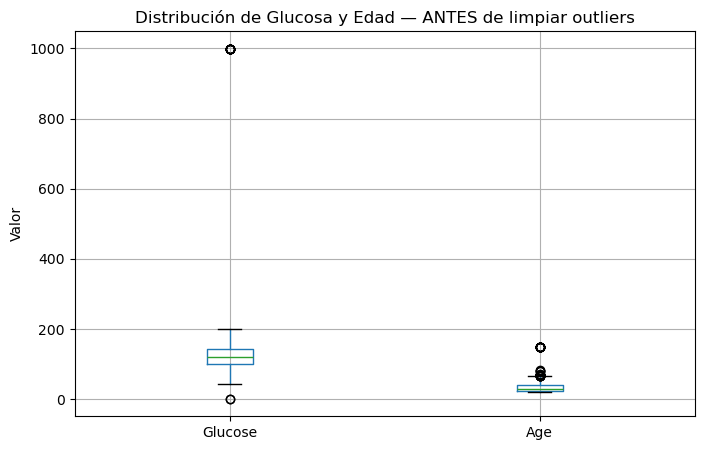

In [17]:
# Boxplot ANTES de eliminar outliers para visualizar el problema
df[['Glucose', 'Age']].boxplot(figsize=(8, 5))
plt.title('Distribución de Glucosa y Edad — ANTES de limpiar outliers')
plt.ylabel('Valor')
plt.show()

In [18]:
def eliminar_outliers(df, condiciones):
    df = df.copy()
    filas_antes = len(df)
    for col, max_val in condiciones.items():
        df = df[df[col] < max_val]
    print(f'Filas antes: {filas_antes} | Filas eliminadas: {filas_antes - len(df)} | Filas restantes: {len(df)}')
    return df

# Glucosa < 400 mg/dL y Edad < 120 años como umbrales clínicos razonables
df = eliminar_outliers(df, {'Glucose': 400, 'Age': 120})

Filas antes: 2000 | Filas eliminadas: 40 | Filas restantes: 1960


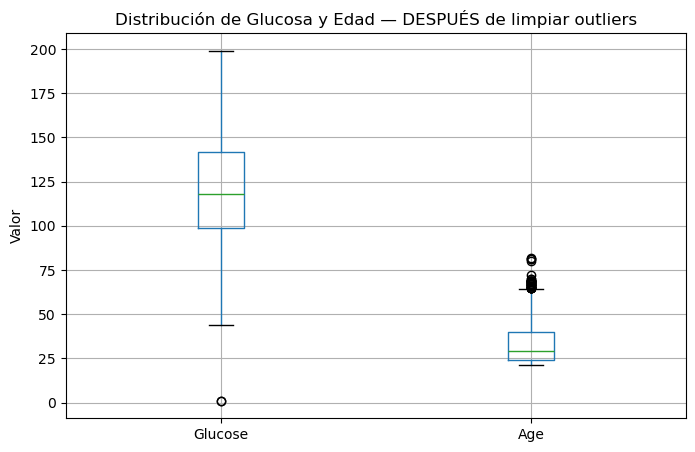

In [19]:
# Boxplot DESPUÉS de eliminar los outliers extremos
df[['Glucose', 'Age']].boxplot(figsize=(8, 5))
plt.title('Distribución de Glucosa y Edad — DESPUÉS de limpiar outliers')
plt.ylabel('Valor')
plt.show()

---
# 3. Convertir valores string en valores numéricos. Utilizando Label encoding (Ordinal) y One hot encoding (Nominal).

Antes de entrar línea por línea, hay una idea clave que se repite en casi todas las herramientas de scikit-learn: el patrón fit y transform. fit significa "aprender" (la herramienta mira los datos y guarda lo que necesita, por ejemplo cuáles categorías existen); transform significa "aplicar" (usa lo aprendido para convertir los datos). Téngalo presente porque aparece dos veces.

Paso 1 — le1 = preprocessing.LabelEncoder()\
Se crea una herramienta (un objeto) llamada le1 que sabe convertir categorías de texto en números enteros. Por ahora está vacía, recién creada; todavía no ha visto ningún dato.

Paso 2 — data1 = df['columna']\
Se extrae la columna a trabajar y se guarda en data1 para trabajar solo con ella.

Paso 3 — le1.fit(data1)\
La herramienta aprende qué categorías distintas existen en la columna. Internamente las ordena alfabéticamente y les asigna un número.

Paso 4 — data_transformada1 = le1.transform(data1)\
Ahora aplica lo aprendido: reemplaza cada texto por su número. Esto ya es Label Encoding listo.

Paso 5 — ohe = preprocessing.OneHotEncoder()\
Se crea una segunda herramienta para el One Hot Encoding.

Paso 6 — d1 = data_transformada1.reshape(-1,1)\
Se reorganizan los datos de una lista a una columna, ya que OneHotEncoder exige formato de tabla (2 dimensiones).

El dataset de diabetes no tiene variables de texto originales. Sin embargo, en medicina es práctica habitual derivar variables categóricas a partir de variables numéricas continuas usando criterios diagnósticos estandarizados.

In [20]:
from sklearn import preprocessing

## a. One hot encoder para variable categórica nominal "NivelGlucosa".

Se crea la variable NivelGlucosa clasificando la glucosa según los criterios diagnósticos de la American Diabetes Association (ADA): Normal (< 100 mg/dL), Prediabetes (100–125 mg/dL) y Diabetes (≥ 126 mg/dL).

In [21]:
# Creamos la variable NivelGlucosa con rangos clínicos ADA
df['NivelGlucosa'] = pd.cut(df['Glucose'],
                             bins=[0, 99, 125, 999],
                             labels=['Normal', 'Prediabetes', 'Diabetes'])

print('Distribución de NivelGlucosa:')
print(df['NivelGlucosa'].value_counts())

Distribución de NivelGlucosa:
NivelGlucosa
Diabetes       788
Prediabetes    675
Normal         497
Name: count, dtype: int64


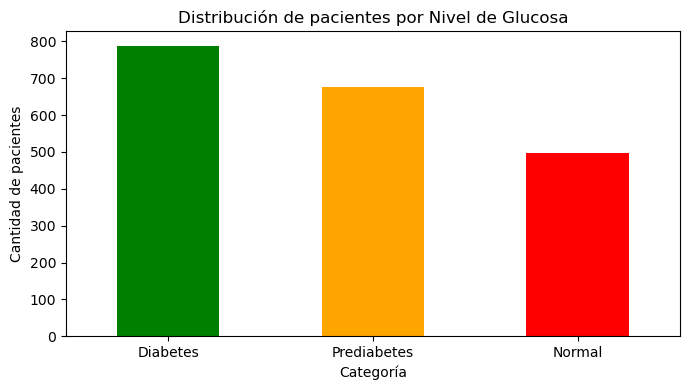

In [22]:
# Gráfico de distribución
df['NivelGlucosa'].value_counts().plot(kind='bar',
                                        color=['green', 'orange', 'red'],
                                        figsize=(7, 4))
plt.title('Distribución de pacientes por Nivel de Glucosa')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
le1 = preprocessing.LabelEncoder()
data1 = df['NivelGlucosa'].astype(str)
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['NivelGlucosa'] = data_transformada1
ohe = preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df = pd.concat([df, data_nueva1], axis=1)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NivelGlucosa,0,1,2
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1.0,0.0,1.0,0.0,0.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0.0,1.0,0.0,1.0,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1.0,0.0,1.0,0.0,0.0
3,1.0,89.0,66.0,NaN,94.0,28.1,0.167,21.0,0.0,1.0,0.0,1.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0
1829,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0
1862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,0.0
1873,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0


In [24]:
# LabelEncoder ordena alfabéticamente: Diabetes=0, Normal=1, Prediabetes=2
new_names = ['Glucosa_Diabetes', 'Glucosa_Normal', 'Glucosa_Prediabetes']
rename_dict = {i: new_names[i] for i in range(len(new_names))}
df.rename(columns=rename_dict, inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NivelGlucosa,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1.0,0.0,1.0,0.0,0.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0.0,1.0,0.0,1.0,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1.0,0.0,1.0,0.0,0.0
3,1.0,89.0,66.0,NaN,94.0,28.1,0.167,21.0,0.0,1.0,0.0,1.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,0.0,1.0,0.0,0.0


## b. One hot encoder para variable categórica nominal "CategoriaBMI".

Se crea la variable CategoriaBMI clasificando el IMC según los criterios de la OMS: Bajo peso (< 18,5), Normal (18,5–24,9), Sobrepeso (25–29,9) y Obesidad (≥ 30).

In [25]:
# Creamos la variable CategoriaBMI con criterios OMS
df['CategoriaBMI'] = pd.cut(df['BMI'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Bajo_peso', 'Normal', 'Sobrepeso', 'Obesidad'])

print('Distribución de CategoriaBMI:')
print(df['CategoriaBMI'].value_counts())

Distribución de CategoriaBMI:
CategoriaBMI
Obesidad     1174
Sobrepeso     460
Normal        300
Bajo_peso      11
Name: count, dtype: int64


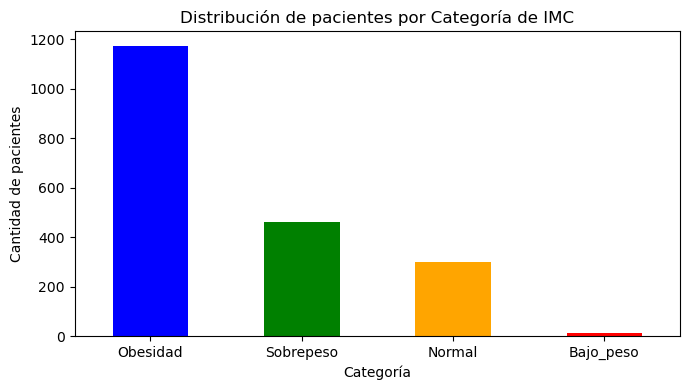

In [26]:
# Gráfico de distribución
df['CategoriaBMI'].value_counts().plot(kind='bar',
                                        color=['blue', 'green', 'orange', 'red'],
                                        figsize=(7, 4))
plt.title('Distribución de pacientes por Categoría de IMC')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de pacientes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
le1 = preprocessing.LabelEncoder()
data1 = df['CategoriaBMI'].astype(str)
le1.fit(data1)
data_transformada1 = le1.transform(data1)
data_transformada1.reshape(-1,1)
df['CategoriaBMI'] = data_transformada1
ohe = preprocessing.OneHotEncoder()
d1 = data_transformada1.reshape(-1,1)
ohe.fit(d1)
data_nueva1 = ohe.transform(d1).toarray()
data_nueva1 = pd.DataFrame(data_nueva1)
df = pd.concat([df, data_nueva1], axis=1)
df.head(20)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NivelGlucosa,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,CategoriaBMI,0,1,2,3,4
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1.0,0.0,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0.0,1.0,0.0,1.0,0.0,3,0.0,0.0,0.0,1.0,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1.0,0.0,1.0,0.0,0.0,1,0.0,1.0,0.0,0.0,0.0
3,1.0,89.0,66.0,NaN,94.0,28.1,0.167,21.0,0.0,1.0,0.0,1.0,0.0,3,0.0,0.0,0.0,1.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,0.0,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0
5,5.0,116.0,74.0,NaN,NaN,25.6,0.201,30.0,0.0,2.0,0.0,0.0,1.0,3,0.0,0.0,0.0,1.0,0.0
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26.0,1.0,1.0,0.0,1.0,0.0,2,0.0,0.0,1.0,0.0,0.0
7,10.0,115.0,NaN,NaN,NaN,35.3,0.134,29.0,0.0,2.0,0.0,0.0,1.0,2,0.0,0.0,1.0,0.0,0.0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0,1.0,0.0,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0
9,8.0,125.0,NaN,NaN,NaN,NaN,0.232,54.0,1.0,2.0,0.0,0.0,1.0,4,0.0,0.0,0.0,0.0,1.0


In [28]:
# LabelEncoder ordena alfabéticamente: Bajo_peso=0, Normal=1, Obesidad=2, Sobrepeso=3
new_names = ['BMI_Bajo_peso', 'BMI_Normal', 'BMI_Obesidad', 'BMI_Sobrepeso']
rename_dict = {i: new_names[i] for i in range(len(new_names))}
df.rename(columns=rename_dict, inplace=True)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,NivelGlucosa,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,CategoriaBMI,BMI_Bajo_peso,BMI_Normal,BMI_Obesidad,BMI_Sobrepeso,4
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1.0,0.0,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0.0,1.0,0.0,1.0,0.0,3,0.0,0.0,0.0,1.0,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1.0,0.0,1.0,0.0,0.0,1,0.0,1.0,0.0,0.0,0.0
3,1.0,89.0,66.0,NaN,94.0,28.1,0.167,21.0,0.0,1.0,0.0,1.0,0.0,3,0.0,0.0,0.0,1.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,0.0,1.0,0.0,0.0,2,0.0,0.0,1.0,0.0,0.0


In [29]:
# Eliminamos las columnas categóricas originales, ya representadas por las columnas OHE
df = df.drop(columns=['NivelGlucosa', 'CategoriaBMI'])
df = df.reset_index(drop=True)
df = df.drop_duplicates()
print(f'Shape tras encoding: {df.shape}')

Shape tras encoding: (1968, 17)


In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,BMI_Bajo_peso,BMI_Normal,BMI_Obesidad,BMI_Sobrepeso,4
0,6.0,148.0,72.0,35.0,NaN,33.6,0.627,50.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,85.0,66.0,29.0,NaN,26.6,0.351,31.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,8.0,183.0,64.0,NaN,NaN,23.3,0.672,32.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.0,89.0,66.0,NaN,94.0,28.1,0.167,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


---
# 4. Corregir valores nulos

Se imputan los valores faltantes reemplazando cada NaN con la media de su columna. La media se calcula solo sobre los valores válidos (pandas ignora NaN por defecto en mean()). Esta estrategia es adecuada cuando el porcentaje de nulos no invalida la representatividad de la media y la distribución es aproximadamente simétrica. Se construye un diccionario con los valores de imputación y se aplica fillna() en una sola operación.

In [31]:
# Nulos antes de imputar
print('Valores nulos ANTES de la imputación:')
print(df.isnull().sum())

Valores nulos ANTES de la imputación:
Pregnancies                   8
Glucose                       8
BloodPressure                94
SkinThickness               648
Insulin                     825
BMI                          23
DiabetesPedigreeFunction      8
Age                           8
Outcome                       8
Glucosa_Diabetes             39
Glucosa_Normal               39
Glucosa_Prediabetes          39
BMI_Bajo_peso                 0
BMI_Normal                    0
BMI_Obesidad                  0
BMI_Sobrepeso                 0
4                             0
dtype: int64


In [32]:
pass  # media calculada dinámicamente en el diccionario

In [33]:
pass  # media calculada dinámicamente en el diccionario

In [34]:
pass  # media calculada dinámicamente en el diccionario

In [35]:
pass  # media calculada dinámicamente en el diccionario

In [36]:
# Imputamos con la media todas las columnas numéricas que tienen NaN
for col in df.columns:
    try:
        if df[col].dtype in ['float64', 'int64'] and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mean())
    except:
        pass

In [37]:
pass  # imputación ya realizada en la celda anterior

In [38]:
# Verificación: nulos DESPUÉS de la imputación — debe ser 0 en todas las columnas
print('Valores nulos DESPUÉS de la imputación:')
print(df.isnull().sum())

Valores nulos DESPUÉS de la imputación:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
Glucosa_Diabetes            0
Glucosa_Normal              0
Glucosa_Prediabetes         0
BMI_Bajo_peso               0
BMI_Normal                  0
BMI_Obesidad                0
BMI_Sobrepeso               0
4                           0
dtype: int64


---
# 5. Eliminar características innecesarias

Se separa la variable objetivo Outcome antes del escalamiento. Esta columna es la etiqueta que el modelo debe predecir y no debe incluirse en el proceso de escalamiento, ya que escalar una variable binaria (0/1) alteraría su interpretación.

In [39]:
# Eliminamos columnas innecesarias antes del escalamiento
# La columna '4' es un artefacto del OHE con nombre numerico
cols_drop = ['Outcome']
if 4 in df.columns: cols_drop.append(4)
df = df.drop(columns=cols_drop)

In [40]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,BMI_Bajo_peso,BMI_Normal,BMI_Obesidad,BMI_Sobrepeso
0,6.0,148.0,72.0,35.000000,124.755906,33.6,0.627,50.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,85.0,66.0,29.000000,124.755906,26.6,0.351,31.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,8.0,183.0,64.0,28.087121,124.755906,23.3,0.672,32.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,89.0,66.0,28.087121,94.000000,28.1,0.167,21.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,137.0,40.0,35.000000,168.000000,43.1,2.288,33.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


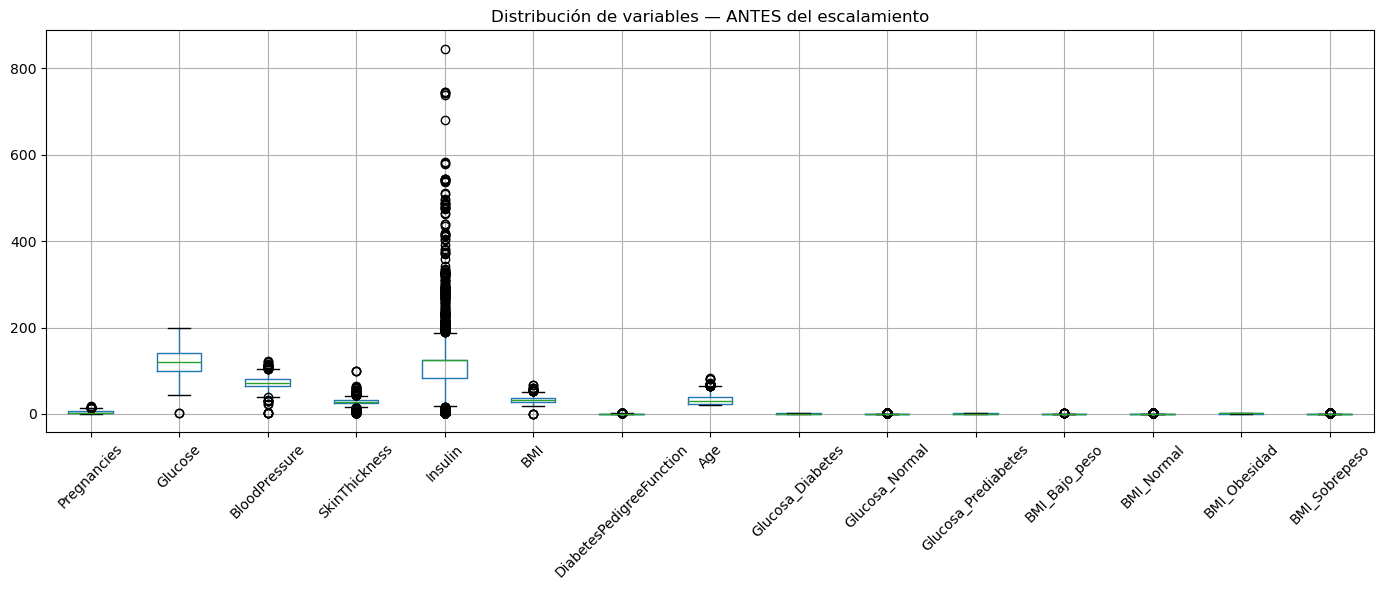

In [41]:
# Boxplot ANTES del escalamiento — solo columnas con nombre string
cols_plot = [c for c in df.columns if isinstance(c, str)]
fig, ax = plt.subplots(figsize=(14, 6))
df[cols_plot].boxplot(ax=ax)
ax.set_title('Distribución de variables — ANTES del escalamiento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

---
# 6. Escalarización de los datos

Las variables del dataset están en escalas muy distintas: Insulin puede llegar a 846 mu U/ml mientras que DiabetesPedigreeFunction oscila entre 0,08 y 2,44. Esta disparidad puede afectar negativamente a algoritmos sensibles a la magnitud de las variables. Se aplican dos técnicas:

**StandardScaler (estandarización):** transforma cada variable para que tenga media = 0 y desviación estándar = 1. Fórmula: z = (x − μ) / σ. Menos sensible a outliers.

**MinMaxScaler (normalización):** transforma los valores al rango [0, 1]. Fórmula: x_norm = (x − x_min) / (x_max − x_min). Preserva la distribución original.

In [42]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## a. Estandarización — StandardScaler

In [43]:
X = df

In [44]:
X = StandardScaler().fit_transform(X)

In [45]:
X

array([[ 0.61683044,  0.82928384, -0.02013844, ..., -0.41907904,
         0.84162541, -0.54995337],
       [-0.86513532, -1.20937846, -0.48225396, ..., -0.41907904,
        -1.18817705,  1.81833598],
       [ 1.20961675,  1.96187401, -0.63629247, ...,  2.38618473,
        -1.18817705, -0.54995337],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  2.38618473,
        -1.18817705, -0.54995337],
       [ 0.        ,  0.        ,  0.        , ..., -0.41907904,
        -1.18817705,  1.81833598],
       [ 0.        ,  0.        ,  0.        , ..., -0.41907904,
        -1.18817705,  1.81833598]])

In [46]:
df_Scaler = pd.DataFrame(X)

In [47]:
df_Scaler.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.616830,0.829284,-0.020138,0.712207,0.000000,0.190248,0.453670,1.462264,1.231205,-0.586987,-0.733469,-0.074972,-0.419079,0.841625,-0.549953
1,-0.865135,-1.209378,-0.482254,0.094050,0.000000,-0.802333,-0.361925,-0.174340,-0.828634,1.738059,-0.733469,-0.074972,-0.419079,-1.188177,1.818336
2,1.209617,1.961874,-0.636292,0.000000,0.000000,-1.270263,0.586648,-0.088203,1.231205,-0.586987,-0.733469,-0.074972,2.386185,-1.188177,-0.549953
3,-0.865135,-1.079940,-0.482254,0.000000,-0.335554,-0.589637,-0.905655,-1.035710,-0.828634,1.738059,-0.733469,-0.074972,-0.419079,-1.188177,1.818336
4,-1.161528,0.473327,-2.484755,0.712207,0.471803,1.537321,5.362017,-0.002066,1.231205,-0.586987,-0.733469,-0.074972,-0.419079,0.841625,-0.549953


In [48]:
df_Scaler.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1968.000000,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03,1.968000e+03
mean,1.805241e-18,-1.101197e-16,-1.480297e-16,7.943059e-17,0.000000,-2.599547e-16,-7.943059e-17,-2.504771e-17,2.166289e-17,6.589129e-17,-7.582011e-17,2.437075e-17,-1.624717e-17,7.220963e-18,1.895503e-17
std,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00,1.000254e+00
min,-1.161528e+00,-3.927595e+00,-5.488505e+00,-2.790680e+00,-1.350206,-4.557405e+00,-1.168655e+00,-1.035710e+00,-8.286338e-01,-5.869867e-01,-7.334692e-01,-7.497232e-02,-4.190790e-01,-1.188177e+00,-5.499534e-01
25%,-8.651353e-01,-7.563424e-01,-6.362925e-01,-3.180540e-01,-0.466477,-7.320720e-01,-6.751608e-01,-7.772988e-01,-8.286338e-01,-5.869867e-01,-7.334692e-01,-7.497232e-02,-4.190790e-01,-1.188177e+00,-5.499534e-01
50%,-2.723490e-01,-1.091480e-01,0.000000e+00,0.000000e+00,0.000000,-9.969909e-03,-2.969137e-01,-3.466136e-01,-8.286338e-01,-5.869867e-01,-7.334692e-01,-7.497232e-02,-4.190790e-01,8.416254e-01,-5.499534e-01
75%,6.168304e-01,6.351255e-01,5.960156e-01,4.031286e-01,0.000000,6.156392e-01,4.455440e-01,6.008936e-01,1.231205e+00,1.290660e-16,1.390948e+00,-7.497232e-02,-4.190790e-01,8.416254e-01,-5.499534e-01
max,4.173548e+00,2.479630e+00,3.830824e+00,7.305876e+00,7.868944,4.940453e+00,5.799366e+00,4.218649e+00,1.231205e+00,1.738059e+00,1.390948e+00,1.333826e+01,2.386185e+00,8.416254e-01,1.818336e+00


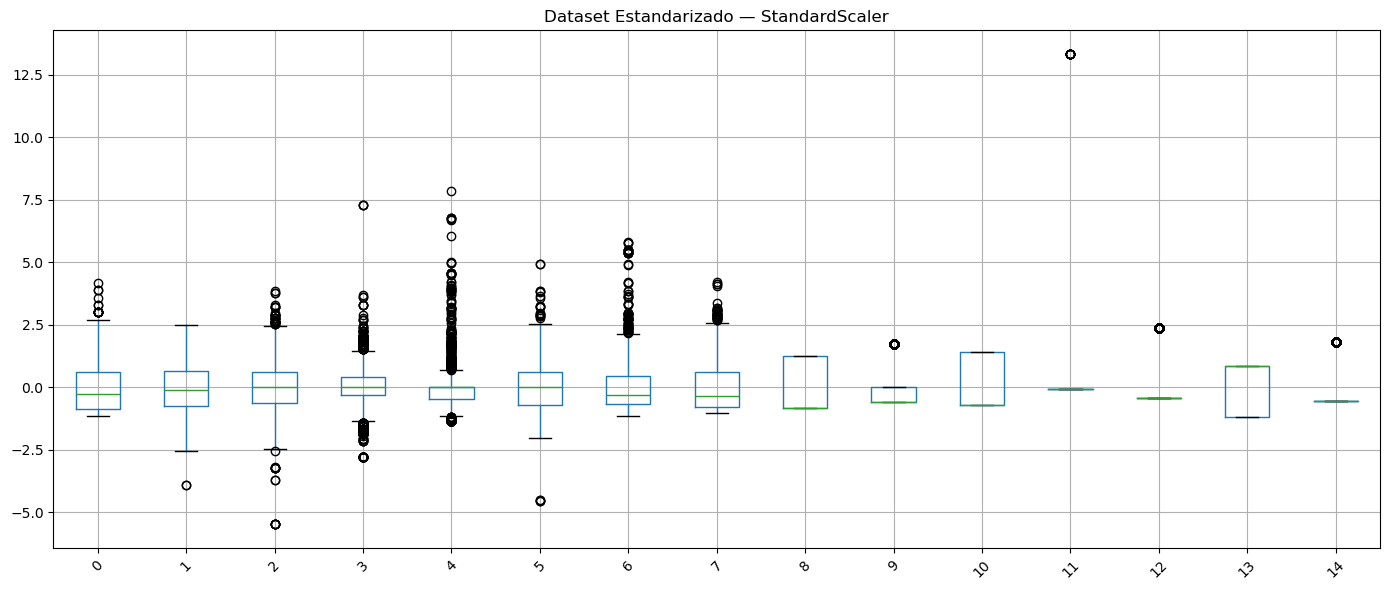

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))
df_Scaler.boxplot(ax=ax)
ax.set_title('Dataset Estandarizado — StandardScaler')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

## b. Normalización — MinMaxScaler

In [50]:
X2 = df

In [51]:
X2 = MinMaxScaler().fit_transform(X2)

In [52]:
X2

array([[0.33333333, 0.74242424, 0.58677686, ..., 0.        , 1.        ,
        0.        ],
       [0.05555556, 0.42424242, 0.53719008, ..., 0.        , 0.        ,
        1.        ],
       [0.44444444, 0.91919192, 0.52066116, ..., 1.        , 0.        ,
        0.        ],
       ...,
       [0.21771542, 0.61299474, 0.58893779, ..., 1.        , 0.        ,
        0.        ],
       [0.21771542, 0.61299474, 0.58893779, ..., 0.        , 0.        ,
        1.        ],
       [0.21771542, 0.61299474, 0.58893779, ..., 0.        , 0.        ,
        1.        ]])

In [53]:
df_MinMax = pd.DataFrame(X2)

In [54]:
df_MinMax.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,0.333333,0.742424,0.586777,0.346939,0.146457,0.499866,0.232824,0.475410,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.055556,0.424242,0.537190,0.285714,0.146457,0.395360,0.115776,0.163934,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.444444,0.919192,0.520661,0.276399,0.146457,0.346093,0.251908,0.180328,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.055556,0.444444,0.537190,0.276399,0.110059,0.417754,0.037744,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.000000,0.686869,0.322314,0.346939,0.197633,0.641695,0.937235,0.196721,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [55]:
df_MinMax.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
count,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000
mean,0.217715,0.612995,0.588938,0.276399,0.146457,0.479835,0.167717,0.197114,0.402281,0.252462,0.345257,0.005589,0.149390,0.585366,0.232215
std,0.187486,0.156113,0.107331,0.099069,0.108497,0.105314,0.143549,0.190367,0.485598,0.430208,0.470837,0.074572,0.356563,0.492784,0.422353
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.055556,0.494949,0.520661,0.244898,0.095858,0.402757,0.070823,0.049180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.166667,0.595960,0.588938,0.276399,0.146457,0.478785,0.125106,0.131148,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.333333,0.712121,0.652893,0.316327,0.146457,0.544654,0.231658,0.311475,1.000000,0.252462,1.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


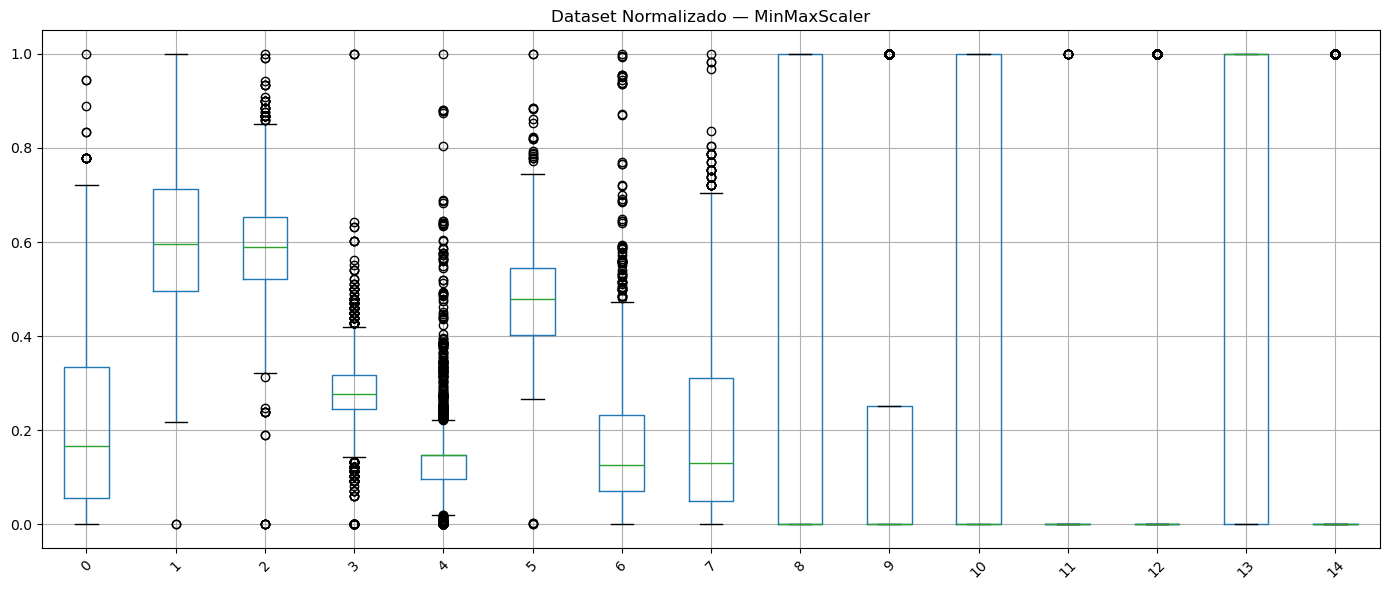

In [56]:
fig, ax = plt.subplots(figsize=(14, 6))
df_MinMax.boxplot(ax=ax)
ax.set_title('Dataset Normalizado — MinMaxScaler')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

---
# 7. Validación técnica del dataset final

Se verifican las condiciones mínimas de calidad del dataset procesado antes de exportarlo. Las comprobaciones cubren casos normales (sin nulos, sin duplicados), casos límite (rangos clínicos válidos) y coherencia dimensional entre variables predictoras. Estas validaciones garantizan trazabilidad y permiten detectar cualquier error introducido en etapas anteriores del pipeline.

In [57]:
# Caso normal: ausencia de valores nulos
assert df.isnull().sum().sum() == 0, 'Quedan valores nulos en el dataset'

# Caso normal: ausencia de filas duplicadas
assert not df.duplicated().any(), 'Existen filas duplicadas'

# Caso límite: Age dentro del rango clínico válido
assert df['Age'].between(1, 120).all(), 'Hay valores de Age fuera del rango clínico'

# Caso límite: Glucose dentro del rango clínico válido
assert df['Glucose'].between(1, 400).all(), 'Hay valores de Glucose fuera del rango clínico'

print('Todas las validaciones pasaron correctamente.')
print(f'Filas: {len(df)} | Columnas: {df.shape[1]} | Nulos: {df.isnull().sum().sum()} | Duplicados: {df.duplicated().sum()}')

Todas las validaciones pasaron correctamente.
Filas: 1968 | Columnas: 15 | Nulos: 0 | Duplicados: 0


In [58]:
# Estructura final del dataset procesado
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1968 entries, 0 to 1995
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               1968 non-null   float64
 1   Glucose                   1968 non-null   float64
 2   BloodPressure             1968 non-null   float64
 3   SkinThickness             1968 non-null   float64
 4   Insulin                   1968 non-null   float64
 5   BMI                       1968 non-null   float64
 6   DiabetesPedigreeFunction  1968 non-null   float64
 7   Age                       1968 non-null   float64
 8   Glucosa_Diabetes          1968 non-null   float64
 9   Glucosa_Normal            1968 non-null   float64
 10  Glucosa_Prediabetes       1968 non-null   float64
 11  BMI_Bajo_peso             1968 non-null   float64
 12  BMI_Normal                1968 non-null   float64
 13  BMI_Obesidad              1968 non-null   float64
 14  BMI_Sobrepeso

In [59]:
df.describe().round(3)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,BMI_Bajo_peso,BMI_Normal,BMI_Obesidad,BMI_Sobrepeso
count,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000,1968.000
mean,3.919,122.373,72.261,28.087,124.756,32.258,0.473,33.024,0.402,0.252,0.345,0.006,0.149,0.585,0.232
std,3.375,30.910,12.987,9.709,91.680,7.054,0.338,11.612,0.486,0.430,0.471,0.075,0.357,0.493,0.422
min,0.000,1.000,1.000,1.000,1.000,0.118,0.078,21.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,1.000,99.000,64.000,25.000,82.000,27.096,0.245,24.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,3.000,119.000,72.261,28.087,124.756,32.188,0.373,29.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000
75%,6.000,142.000,80.000,32.000,124.756,36.600,0.624,40.000,1.000,0.252,1.000,0.000,0.000,1.000,0.000
max,18.000,199.000,122.000,99.000,846.000,67.100,2.436,82.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [60]:
# Vista del dataset final con todos los nombres de columnas
print('Columnas del dataset final:')
print(list(df.columns))
print(f'Shape: {df.shape}')
df.head()

Columnas del dataset final:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucosa_Diabetes', 'Glucosa_Normal', 'Glucosa_Prediabetes', 'BMI_Bajo_peso', 'BMI_Normal', 'BMI_Obesidad', 'BMI_Sobrepeso']
Shape: (1968, 15)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Glucosa_Diabetes,Glucosa_Normal,Glucosa_Prediabetes,BMI_Bajo_peso,BMI_Normal,BMI_Obesidad,BMI_Sobrepeso
0,6.0,148.0,72.0,35.000000,124.755906,33.6,0.627,50.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,85.0,66.0,29.000000,124.755906,26.6,0.351,31.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,8.0,183.0,64.0,28.087121,124.755906,23.3,0.672,32.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,89.0,66.0,28.087121,94.000000,28.1,0.167,21.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,137.0,40.0,35.000000,168.000000,43.1,2.288,33.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


---
# 8. Exportación del dataset procesado

Se exportan los datasets resultantes a la carpeta data/processed/ para su uso en la Fase 3 del proyecto. Se generan tres archivos: el dataset limpio con variables predictoras, el estandarizado y el normalizado, permitiendo elegir el escalamiento más adecuado según el algoritmo de modelamiento.

In [61]:
import os
ruta_proc = r'C:\Vulcan_Home\mcdia500-programacion-cd-g6\data\processed'
os.makedirs(ruta_proc, exist_ok=True)

df.to_csv(os.path.join(ruta_proc, 'diabetes_processed.csv'), index=False, sep=';')
pd.DataFrame(X).to_csv(os.path.join(ruta_proc, 'diabetes_standardized.csv'), index=False, sep=';')
pd.DataFrame(X2).to_csv(os.path.join(ruta_proc, 'diabetes_normalized.csv'), index=False, sep=';')

print('Datasets exportados correctamente a data/processed/')
print(f'  diabetes_processed.csv    — {len(df)} filas x {df.shape[1]} columnas')
print(f'  diabetes_standardized.csv — estandarizado con StandardScaler')
print(f'  diabetes_normalized.csv   — normalizado con MinMaxScaler')

Datasets exportados correctamente a data/processed/
  diabetes_processed.csv    — 1968 filas x 15 columnas
  diabetes_standardized.csv — estandarizado con StandardScaler
  diabetes_normalized.csv   — normalizado con MinMaxScaler
